<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Lakonishok%2C%20J.%2C%20Shleifer%2C%20A.%2C%20%26%20Vishny%2C%20R.%20W.%20(1994).%20Contrarian%20investment%2C%20extrapolation%2C%20and%20risk/Contrarian_investment%2C_extrapolation%2C_and_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This uses "25 Portfolios Formed on Size and Book-to-Market" data

In [4]:
#from google.colab import files

# This will open a file picker
#uploaded = files.upload()

In [5]:
import pandas as pd

# Read the Fama-French 25 Portfolios file as a fixed-width file
df = pd.read_csv(
    '25_Portfolios_5x5.csv',
    skiprows=15  # Skip the top metadata lines (adjust if needed)
)
df.rename(columns={'Unnamed: 0': 'Dates'}, inplace=True)
# Preview the first rows
df = df.iloc[:-1]  # selects all rows except the last one
df.head()

,Dates,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,SMALL HiBM,ME2 BM1,ME2 BM2,ME2 BM3,ME2 BM4,...,ME4 BM1,ME4 BM2,ME4 BM3,ME4 BM4,ME4 BM5,BIG LoBM,ME5 BM2,ME5 BM3,ME5 BM4,BIG HiBM
0,192607,5.8276,-1.7006,0.5118,-2.1477,1.9583,1.2118,2.4107,0.6056,-2.6082,...,1.5376,1.5460,1.3389,0.2765,2.4678,3.3248,6.0909,2.0285,3.1263,0.5623
1,192608,-2.0206,-8.0282,1.3968,2.1483,8.5104,2.3620,-0.7525,3.8984,0.2299,...,1.3858,3.8587,1.9738,2.1336,5.3422,1.0169,4.1975,1.9769,5.4924,7.7576
2,192609,-4.8291,-2.6806,-4.3417,-3.2683,0.8586,-2.6849,-0.5252,1.0789,-3.2877,...,1.6897,-0.5246,-1.7724,1.4806,0.8730,-1.2951,3.6610,0.1384,-0.7497,-2.4284
3,192610,-9.3633,-3.5519,-3.5024,3.4413,-2.5452,-2.8014,-4.4191,-5.0767,-8.0271,...,-3.9136,-2.6528,-2.1058,-3.2532,-5.3525,-2.7382,-3.0061,-2.2467,-4.6725,-5.8129
4,192611,5.5888,4.1877,2.4384,-4.4495,0.5110,3.1023,-1.7317,3.0425,4.9538,...,3.4492,2.3823,3.7315,5.1102,1.8213,4.4331,2.5355,1.5280,3.6596,2.5636


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate annualized return for a rolling window
def get_annual_return(window):
    if window.isnull().sum() > 6:  # Skip if more than 6 months missing
        return np.nan
    return (np.prod(1 + window) ** (12 / len(window))) - 1

# 1. Prepare the data
df_clean = df.copy()
df_clean['Dates'] = df_clean['Dates'].astype(str).str.strip()
df_clean = df_clean[df_clean['Dates'].str.len() == 6]  # Keep only monthly data
df_clean['Dates'] = pd.to_datetime(df_clean['Dates'], format='%Y%m')
df_clean = df_clean.drop_duplicates(subset=['Dates'])
df_clean.set_index('Dates', inplace=True)
df_clean.sort_index(inplace=True)

# 2. Handle Small Cap portfolios
small_caps = df_clean[['SMALL HiBM', 'SMALL LoBM']].apply(pd.to_numeric, errors='coerce')
small_caps = small_caps.replace([-99.99, -99.0, -99.9, -999], np.nan) / 100

# 3. Handle Large Cap portfolios
large_caps = df_clean[['BIG HiBM', 'BIG LoBM']].apply(pd.to_numeric, errors='coerce')
large_caps = large_caps.replace([-99.99, -99.0, -99.9, -999], np.nan) / 100

# 4. Calculate 10-year (120 month) rolling annualized returns
rolling_small_val = small_caps['SMALL HiBM'].rolling(window=120).apply(get_annual_return) * 100
rolling_small_glam = small_caps['SMALL LoBM'].rolling(window=120).apply(get_annual_return) * 100

rolling_large_val = large_caps['BIG HiBM'].rolling(window=120).apply(get_annual_return) * 100
rolling_large_glam = large_caps['BIG LoBM'].rolling(window=120).apply(get_annual_return) * 100

print("Rolling returns ready.")
print(f"Data cleaned. Available from {small_caps.index.min().year} to {small_caps.index.max().year}")

Rolling returns ready.
Data cleaned. Available from 1926 to 2026


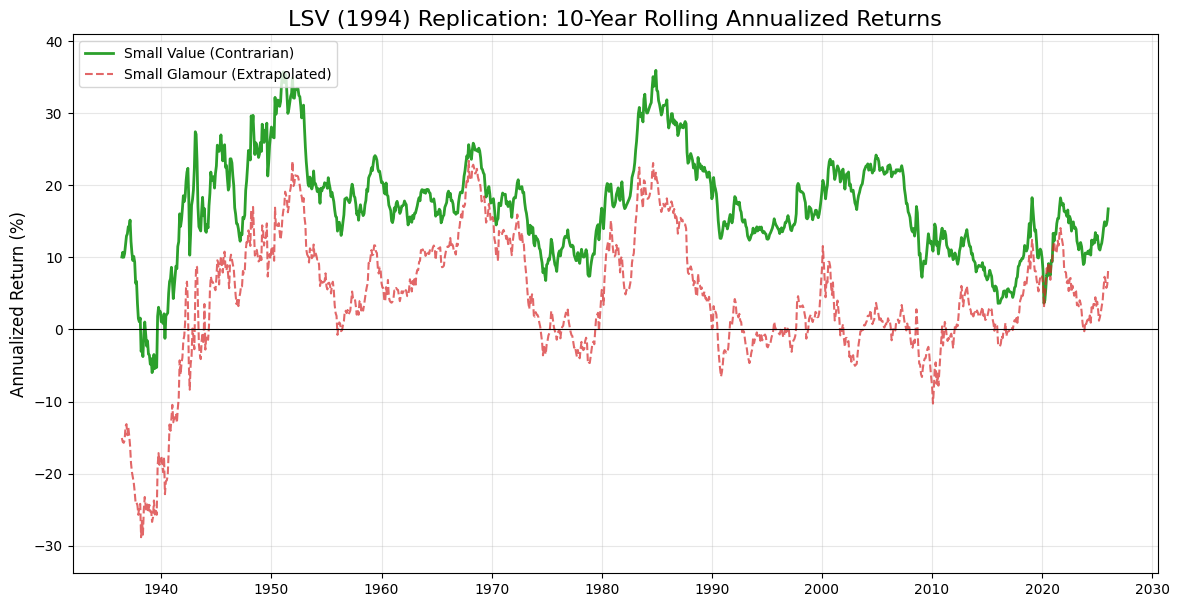

In [8]:
plt.figure(figsize=(14, 7))

# Plot Small Cap rolling returns
plt.plot(rolling_small_val, label='Small Value (Contrarian)', color='#2ca02c', linewidth=2)
plt.plot(rolling_small_glam, label='Small Glamour (Extrapolated)', color='#d62728', linestyle='--', alpha=0.7)

# Chart formatting
plt.title('LSV (1994) Replication: 10-Year Rolling Annualized Returns', fontsize=16)
plt.ylabel('Annualized Return (%)', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8)  # Zero line
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')

# Auto-scale Y-axis to focus on data range (ignoring NaNs)
y_min = min(rolling_small_val.min(), rolling_small_glam.min())
y_max = max(rolling_small_val.max(), rolling_small_glam.max())
plt.ylim(y_min - 5, y_max + 5)

plt.show()

The plot illustrates how different investment approaches perform over time, linking strategy, projection, and risk. The green line shows the “Small Value (Contrarian)” strategy, where investors deliberately buy undervalued stocks others are avoiding, highlighting periods when going against the crowd pays off. The dashed red line represents “Small Glamour (Extrapolated)” returns, projecting past trends forward, which can overstate future gains. By comparing the two, the chart also reveals differences in risk: larger swings indicate higher volatility, while smoother trends suggest stability. Overall, it shows how contrarian strategies, trend extrapolation, and risk interact in long-term investing.


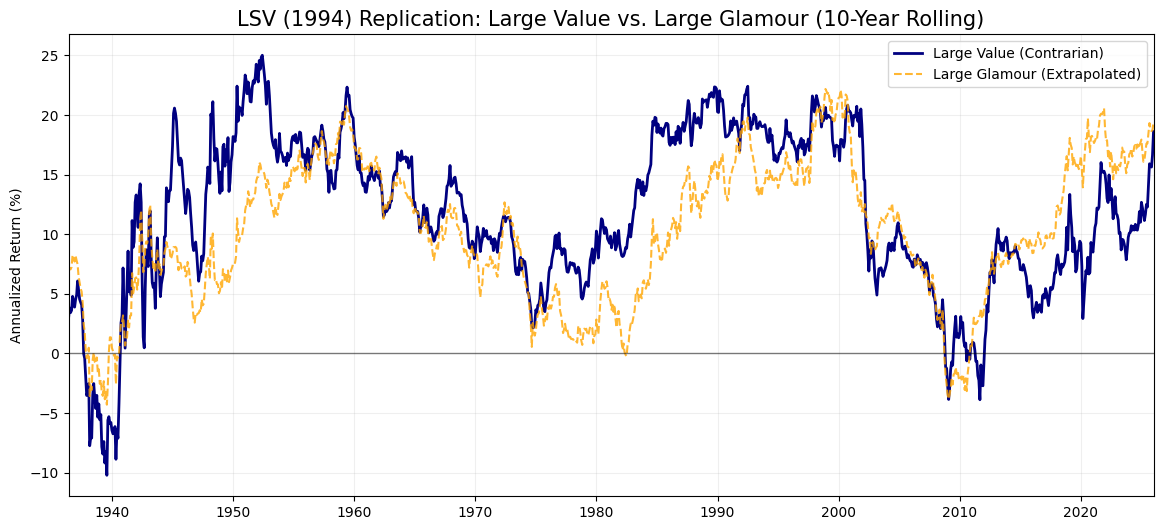

In [9]:
plt.figure(figsize=(14, 6))

# Plotting the lines
plt.plot(rolling_large_val, label='Large Value (Contrarian)', color='navy', linewidth=2)
plt.plot(rolling_large_glam, label='Large Glamour (Extrapolated)', color='orange', linestyle='--', alpha=0.8)

# Formatting
plt.title('LSV (1994) Replication: Large Value vs. Large Glamour (10-Year Rolling)', fontsize=15)
plt.ylabel('Annualized Return (%)')
plt.axhline(0, color='black', linewidth=1, alpha=0.5)
plt.grid(True, alpha=0.2)
plt.legend()

# Zoom in to the data (ignoring the empty start of the series)
plt.xlim(rolling_large_val.dropna().index[0], rolling_large_val.index[-1])
plt.show()

The chart compares long-term performance of large-cap investment strategies, showing both “Large Value (Contrarian)” in navy and “Large Glamour (Extrapolated)” in dashed orange. The contrarian value line highlights how disciplined investors target undervalued large stocks, often going against prevailing market sentiment, while the extrapolated glamour line projects past trends of popular large stocks forward, which can overstate future returns. The rolling 10-year returns reveal differences in risk, with bigger swings indicating higher volatility and smoother stretches reflecting relative stability. By focusing on the actual data range and including a zero line for reference, the plot clearly visualizes how strategy, trend projection, and risk interact over time in large-cap markets.

In [11]:
# 5. Summary statistics for rolling returns
def summarize_rolling_returns(rolling_series, name):
    summary = {
        'Mean (%)': rolling_series.mean(),
        'Median (%)': rolling_series.median(),
        'Std Dev (%)': rolling_series.std(),
        'Min (%)': rolling_series.min(),
        'Max (%)': rolling_series.max(),
        '25th Percentile (%)': rolling_series.quantile(0.25),
        '75th Percentile (%)': rolling_series.quantile(0.75),
        'Available Data Points': rolling_series.count()
    }
    print(f"\nSummary Statistics for {name}:")
    for k, v in summary.items():
        print(f"{k}: {v:.2f}")

# Apply the summary function to each portfolio
summarize_rolling_returns(rolling_small_val, 'Small Cap Value (SMALL HiBM)')
summarize_rolling_returns(rolling_small_glam, 'Small Cap Growth (SMALL LoBM)')
summarize_rolling_returns(rolling_large_val, 'Large Cap Value (BIG HiBM)')
summarize_rolling_returns(rolling_large_glam, 'Large Cap Growth (BIG LoBM)')


Summary Statistics for Small Cap Value (SMALL HiBM):
Mean (%): 16.83
Median (%): 16.74
Std Dev (%): 7.14
Min (%): -5.98
Max (%): 35.93
25th Percentile (%): 12.50
75th Percentile (%): 21.16
Available Data Points: 1076.00

Summary Statistics for Small Cap Growth (SMALL LoBM):
Mean (%): 4.16
Median (%): 3.86
Std Dev (%): 8.94
Min (%): -28.81
Max (%): 23.39
25th Percentile (%): -0.22
75th Percentile (%): 10.20
Available Data Points: 1076.00

Summary Statistics for Large Cap Value (BIG HiBM):
Mean (%): 11.71
Median (%): 11.50
Std Dev (%): 6.69
Min (%): -10.22
Max (%): 25.00
25th Percentile (%): 7.48
75th Percentile (%): 17.45
Available Data Points: 1076.00

Summary Statistics for Large Cap Growth (BIG LoBM):
Mean (%): 10.22
Median (%): 10.16
Std Dev (%): 5.88
Min (%): -4.30
Max (%): 22.18
25th Percentile (%): 6.22
75th Percentile (%): 15.21
Available Data Points: 1076.00


In [14]:
# 7. Compare total period returns (cumulative) for all portfolios
def compare_total_returns(portfolio_dict):
    results = {}
    for name, series in portfolio_dict.items():
        clean_series = series.dropna()  # Remove missing values
        if clean_series.empty:
            results[name] = np.nan
        else:
            results[name] = np.prod(1 + clean_series) - 1  # Total cumulative return
    # Print results nicely
    print("\nTotal Cumulative Returns for Each Portfolio:")
    for name, cum_return in results.items():
        print(f"{name}: {cum_return*100:.2f}%")
    return results

# Define portfolios to compare
portfolios = {
    'Small Cap Value (SMALL HiBM)': small_caps['SMALL HiBM'],
    'Small Cap Growth (SMALL LoBM)': small_caps['SMALL LoBM'],
    'Large Cap Value (BIG HiBM)': large_caps['BIG HiBM'],
    'Large Cap Growth (BIG LoBM)': large_caps['BIG LoBM']
}

# Run comparison
total_returns = compare_total_returns(portfolios)


Total Cumulative Returns for Each Portfolio:
Small Cap Value (SMALL HiBM): 250709855.98%
Small Cap Growth (SMALL LoBM): 1227.73%
Large Cap Value (BIG HiBM): 4727502.42%
Large Cap Growth (BIG LoBM): 1725031.42%
